# DSLR: Datascience × Logistic Regression
## Harry Potter and a Data Scientist

---

> **Objectif** : Construire un Chapeau de Répartition magique en utilisant la régression logistique et la descente de gradient.  
> **Mission** : Classifier les étudiants de Poudlard dans leurs maisons à partir de leurs notes de cours.

---

Ce notebook explique en détail l'implémentation complète d'un pipeline de machine learning **sans utiliser de bibliothèques ML externes** (pas de pandas, scikit-learn, numpy avec fonctions prêtes à l'emploi).

**Projet développé dans le cadre du cursus IA/ML de 42 Paris**

## ■ Table des matières

1. [Installation et Configuration](#installation-et-configuration)
2. [Partie 1 : Analyse des Données (describe.py)](#partie-1)
3. [Partie 2 : Visualisation des Données](#partie-2)
   - 2.1 Histogrammes
   - 2.2 Scatter Plots
   - 2.3 Pair Plot
4. [Partie 3 : Régression Logistique](#partie-3)
   - 3.1 Théorie
   - 3.2 Entraînement (logreg_train.py)
   - 3.3 Prédiction (logreg_predict.py)
5. [Résultats et Conclusion](#resultats-et-conclusion)

<a id="installation-et-configuration"></a>
## ■ Installation et Configuration

Nous commençons par cloner le repository GitHub contenant tout le code du projet.

In [21]:
import os

REPO_URL = "https://github.com/ai-dg/dslr.git"

if not os.path.exists("dslr"):
    print("[>] Cloning repository...")
    get_ipython().system(f"git clone {REPO_URL}")
    print("[+] Repository cloned successfully")
else:
    get_ipython().system("rm -rf ./dslr")
    get_ipython().system(f"git clone {REPO_URL}")
    print("[+] Repository already present, updated")

# Configuration matplotlib pour afficher les graphiques dans le notebook
%matplotlib inline

# Changer de répertoire
os.chdir("dslr")
print(f"[+] Current directory: {os.getcwd()}")

[>] Cloning repository...
Cloning into 'dslr'...
remote: Enumerating objects: 171, done.
remote: Counting objects: 100% (171/171), done.
remote: Compressing objects: 100% (147/147), done.
remote: Total 171 (delta 64), reused 102 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (171/171), 7.72 MiB | 7.45 MiB/s, done.
Resolving deltas: 100% (64/64), done.
[+] Repository cloned successfully
[+] Current directory: /home/dagudelo/Projects/dslr/dslr/dslr/dslr


<a id="partie-1"></a>
## ■ Partie 1 : Analyse des Données (describe.py)

### Objectif
Créer un programme qui analyse statistiquement toutes les colonnes numériques du dataset et affiche des métriques descriptives.

### Métriques calculées manuellement
- **Count** : Nombre d'observations
- **Mean** : Moyenne
- **Std** : Écart-type
- **Min/Max** : Valeurs extrêmes
- **25%, 50%, 75%** : Quartiles
- **Range** : Étendue (Max - Min)
- **Variance** : Variance
- **CV (%)** : Coefficient de variation
- **IQR** : Interquartile Range
- **Low/High IQR** : Bornes pour détecter les outliers
- **Skewness** : Asymétrie de la distribution
- **Kurtosis** : Aplatissement de la distribution

### ⚠️ Contrainte importante
**Toutes ces statistiques doivent être calculées manuellement** - aucune fonction prête à l'emploi n'est autorisée (pas de `.mean()`, `.std()`, etc.)

In [12]:
# Exécution de describe.py
!python3 describe.py datasets/dataset_train.csv

                          Arithmancy         Astronomy         Herbology  Defense Again...        Divination    Muggle Studies     Ancient Runes  History of Ma...   Transfiguration           Potions  Care of Magic...            Charms            Flying
Count                    1600.000000       1600.000000       1600.000000       1600.000000       1600.000000       1600.000000       1600.000000       1600.000000       1600.000000       1600.000000       1600.000000       1600.000000       1600.000000
Mean                    48579.835625         39.001188          1.117486         -0.380349          3.077033       -219.677010        484.903483          2.883461       1008.207386          5.838803         -0.052091       -243.374409         21.958012
Std                     17988.080002        515.095872          5.168086          5.162293          4.133049        482.113962        127.714870          4.392095        154.882677          3.221012          0.959265          8.783640       

### Explication du code describe.py

Le fichier `describe.py` implémente plusieurs fonctions clés :

1. **`ft_recovering_data_from_dataset(path)`** : Lit le CSV et convertit les colonnes numériques en float
2. **`ft_recover_numeric_values_from_columns(data)`** : Identifie les colonnes numériques
3. **`ft_recover_stats_from_numeric_cols(data)`** : Calcule toutes les statistiques manuellement
4. **`ft_show_stats_in_terminal(data)`** : Affiche les résultats formatés

#### Moments statistiques

Les statistiques avancées (skewness, kurtosis) sont basées sur le concept de **moments statistiques**. Un moment d'ordre n suit la formule générale :

$$Moment_n = \frac{1}{N} \sum_{i=1}^{N} (X^{(i)} - \mu)^n$$

où $\mu$ est la moyenne et $n$ est l'ordre du moment.

**Les moments permettent d'analyser différentes propriétés** :
- **Ordre 1** : Moyenne (tendance centrale)
- **Ordre 2** : Variance (dispersion)
- **Ordre 3** : Skewness (asymétrie)
- **Ordre 4** : Kurtosis (aplatissement)

**Points techniques importants** :

- **Variance** : $\sigma^2 = \frac{\Sigma(x_i - \mu)^2}{n}$
- **Écart-type** : $\sigma = \sqrt{\frac{\Sigma(x_i - \mu)^2}{n-1}}$ (correction de Bessel pour un échantillon)
- **Quartiles** : Interpolation linéaire pour les valeurs entre deux points
  - $k = (n-1) \times p$ où $p$ est le percentile (0.25, 0.5, 0.75)
  - $f = \lfloor k \rfloor$ (indice inférieur)
  - $c = f + 1$ (indice supérieur)
  - $valeur = liste[f] + (liste[c] - liste[f]) \times (k - f)$
- **Skewness** : $\frac{1}{n} \sum \frac{(x_i - \mu)^3}{\sigma^3}$
  - Skew > 0 : queue longue à droite
  - Skew < 0 : queue longue à gauche
- **Kurtosis (excess)** : $\frac{1}{n} \sum \frac{(x_i - \mu)^4}{\sigma^4} - 3$
  - Kurtosis > 0 : distribution pointue avec beaucoup d'outliers
  - Kurtosis < 0 : distribution plate
  - Le "-3" centre la distribution normale sur 0

#### Interprétation des résultats

**Transfiguration** :
- Skewness: -5.85 → très fortement asymétrique à gauche
- Kurtosis: 35.17 → distribution très pointue avec valeurs extrêmes concentrées
- **Interprétation** : Matière très biaisée, nécessite transformation logarithmique

**Astronomy** :
- Std: 515.10 (très élevé par rapport à la moyenne)
- **Interprétation** : Dispersion importante, valeurs extrêmes dans les deux sens

**Muggle Studies & Charms** :
- Moyennes négatives → Possible erreur de données ou normalisation
- **Interprétation** : Vérifier l'origine des données

Ces analyses guident le preprocessing nécessaire avant l'entraînement du modèle.

<a id="partie-2"></a>
## ■ Partie 2 : Visualisation des Données

La visualisation est un outil puissant pour comprendre les données et détecter des patterns ou anomalies.

### 2.1 Histogrammes (histogram.py)

**Question à répondre** : Quelle matière de Poudlard a une distribution de scores homogène entre les quatre maisons ?

L'histogramme montre la distribution des scores par maison pour chaque matière.


▸ Exemples d'histogrammes générés :


Ancient Runes.png:


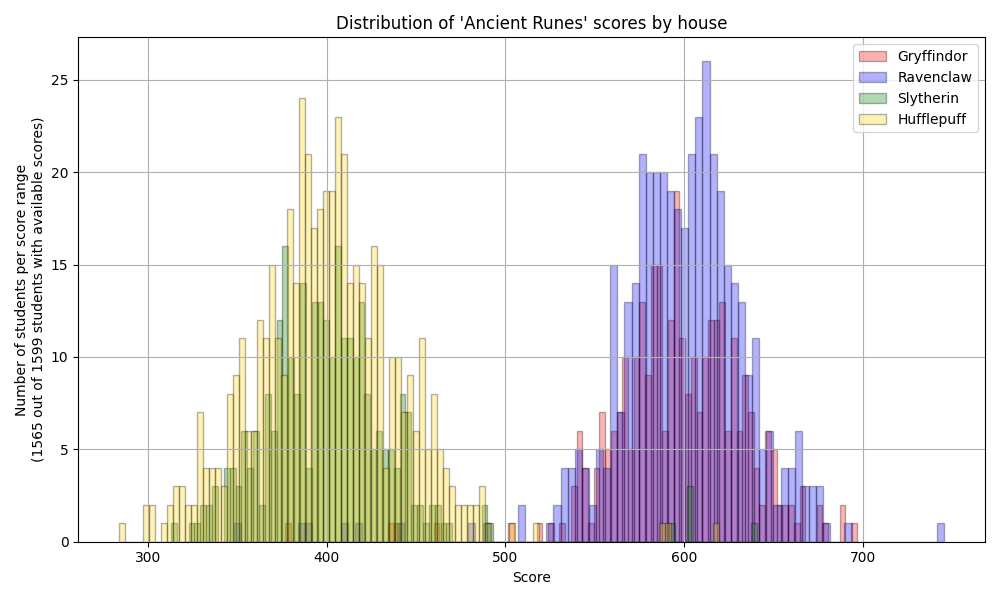


Arithmancy.png:


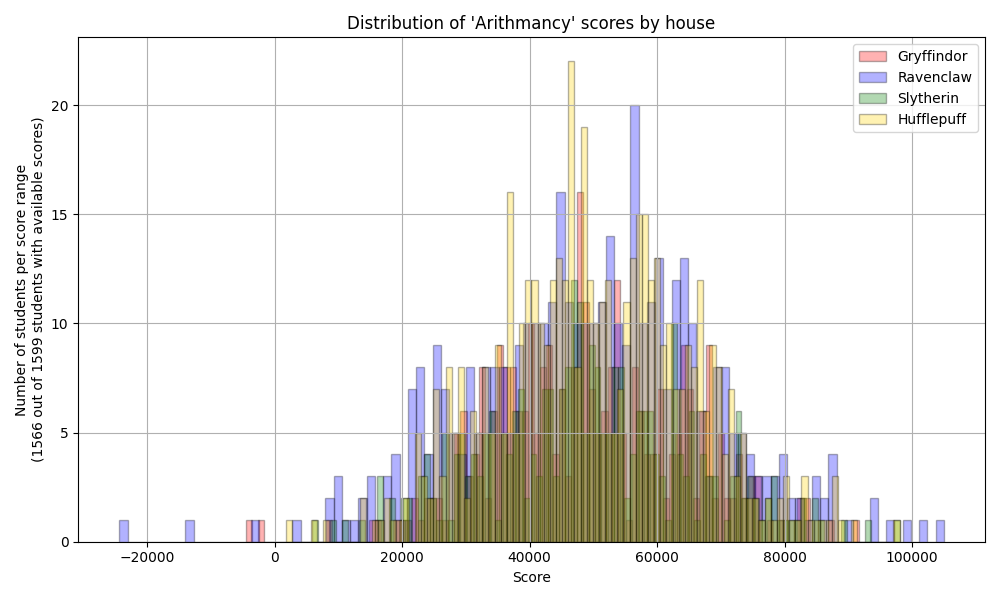


Astronomy.png:


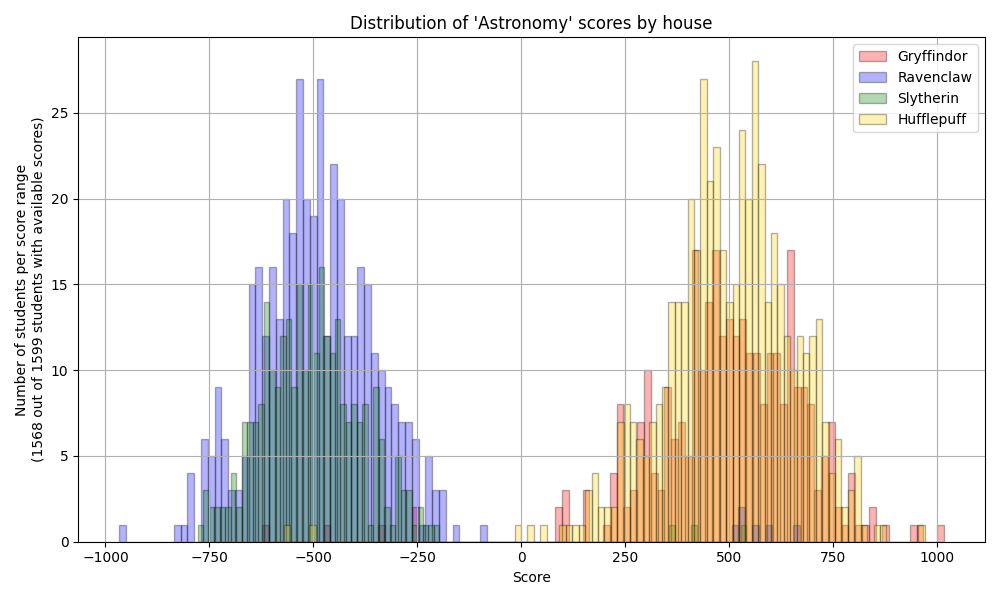

In [13]:
# Génération des histogrammes
!python3 histogram.py datasets/dataset_train.csv

# Affichage de quelques histogrammes générés
from IPython.display import Image, display
import os

print("\n▸ Exemples d'histogrammes générés :\n")
histogram_dir = "plots_histogram"
if os.path.exists(histogram_dir):
    # Afficher les 3 premiers histogrammes
    files = sorted([f for f in os.listdir(histogram_dir) if f.endswith('.png')])[:3]
    for filename in files:
        print(f"\n{filename}:")
        display(Image(f"{histogram_dir}/{filename}", width=600))

### 2.2 Scatter Plots (scatter_plot.py)

**Question à répondre** : Quelles sont les deux features qui sont similaires (forte corrélation) ?

Le scatter plot montre la relation entre deux matières et calcule leur coefficient de corrélation de Pearson.

Correlation between Astronomy and Muggle Studies: -0.5785
Correlation between Arithmancy and Divination: -0.0035
Correlation between Muggle Studies and Care of Magical Creatures: 0.0504
Correlation between Astronomy and Defense Against the Dark Arts: -1.0000
Correlation between Arithmancy and Care of Magical Creatures: -0.0421
Correlation between Arithmancy and History of Magic: -0.0698
Correlation between Potions and Flying: -0.5586
Correlation between Astronomy and Flying: 0.5240
Correlation between Potions and Care of Magical Creatures: 0.0035
Correlation between Arithmancy and Ancient Runes: 0.0770

▸ Exemples de scatter plots générés :


Arithmancy_vs_Ancient Runes.png:


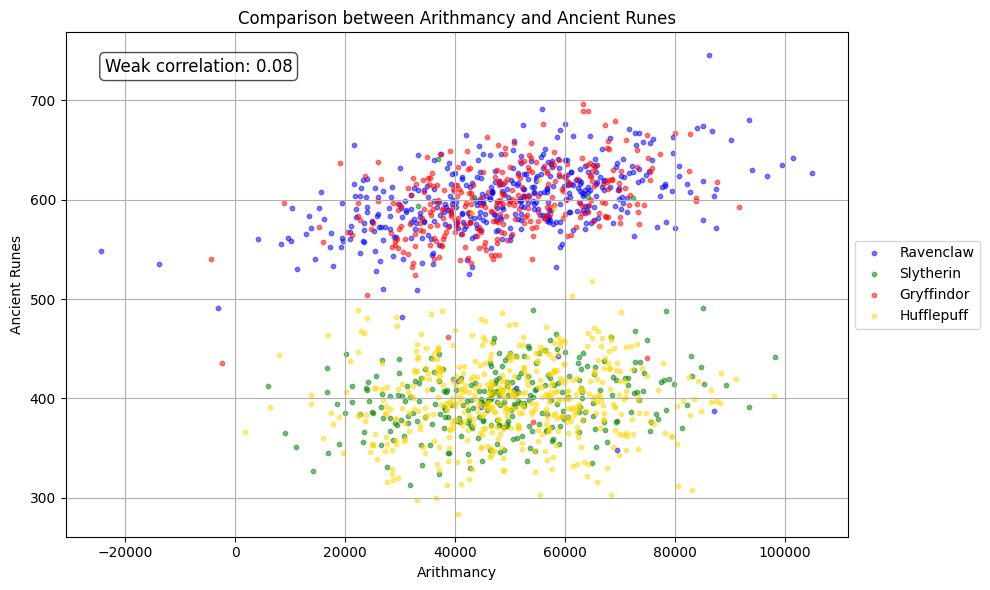


Arithmancy_vs_Care of Magical Creatures.png:


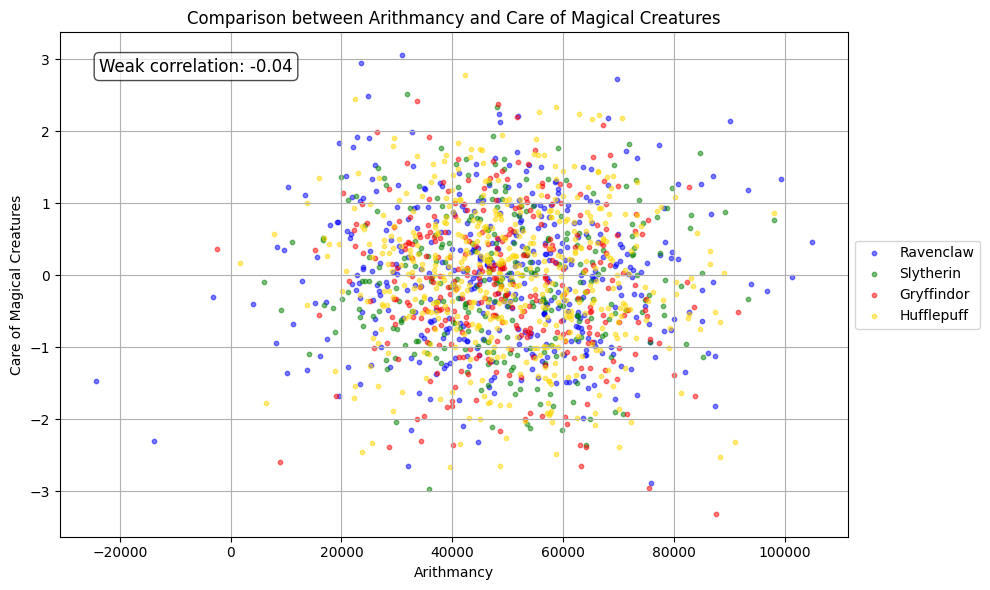


Arithmancy_vs_Divination.png:


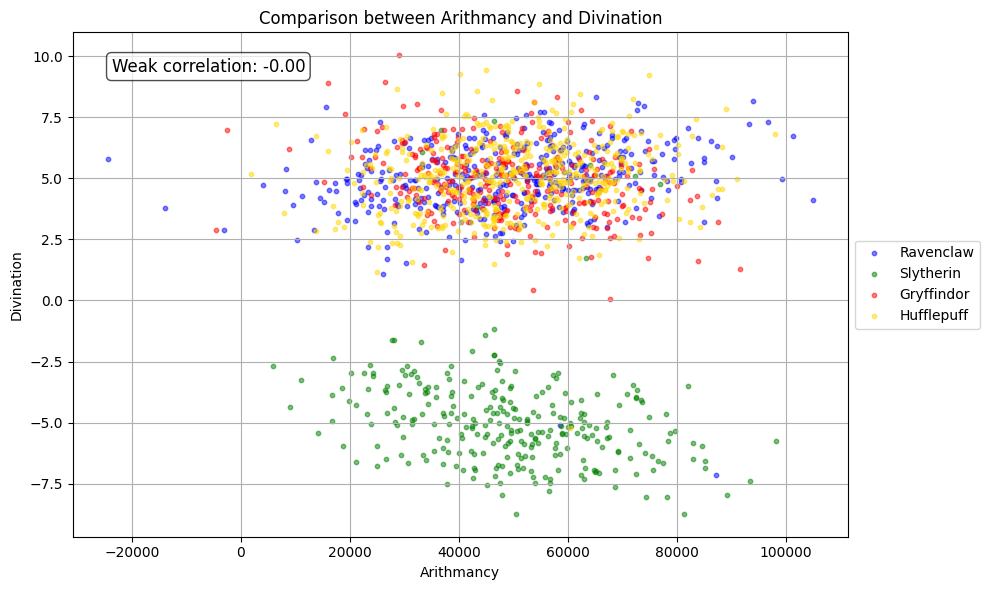

In [14]:
# Génération des scatter plots (10 paires aléatoires)
!python3 scatter_plot.py datasets/dataset_train.csv

# Affichage de quelques scatter plots générés
from IPython.display import Image, display
import os

print("\n▸ Exemples de scatter plots générés :\n")
scatter_dir = "plots_scatter"
if os.path.exists(scatter_dir):
    # Afficher les 3 premiers scatter plots
    files = sorted([f for f in os.listdir(scatter_dir) if f.endswith('.png')])[:3]
    for filename in files:
        print(f"\n{filename}:")
        display(Image(f"{scatter_dir}/{filename}", width=600))

**Formule de corrélation de Pearson** :
$$r = \frac{\Sigma(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\Sigma(x_i - \bar{x})^2}\sqrt{\Sigma(y_i - \bar{y})^2}}$$

- **|r| > 0.7** : Corrélation forte
- **0.3 ≤ |r| ≤ 0.7** : Corrélation modérée  
- **|r| < 0.3** : Corrélation faible

### 2.3 Pair Plot (pair_plot.py)

**Question à répondre** : Quelles features allez-vous utiliser pour votre régression logistique ?

Le pair plot affiche une matrice de tous les scatter plots entre toutes les paires de features, permettant d'identifier visuellement les relations et de sélectionner les features les plus pertinentes.

['Arithmancy', 'Astronomy', 'Herbology', 'Defense Against the Dark Arts', 'Divination', 'Muggle Studies', 'Ancient Runes', 'History of Magic', 'Transfiguration', 'Potions', 'Care of Magical Creatures', 'Charms', 'Flying']
['Ravenclaw', 'Slytherin', 'Gryffindor', 'Hufflepuff']

▸ Pair plot généré :


pair_plot_colored.png:


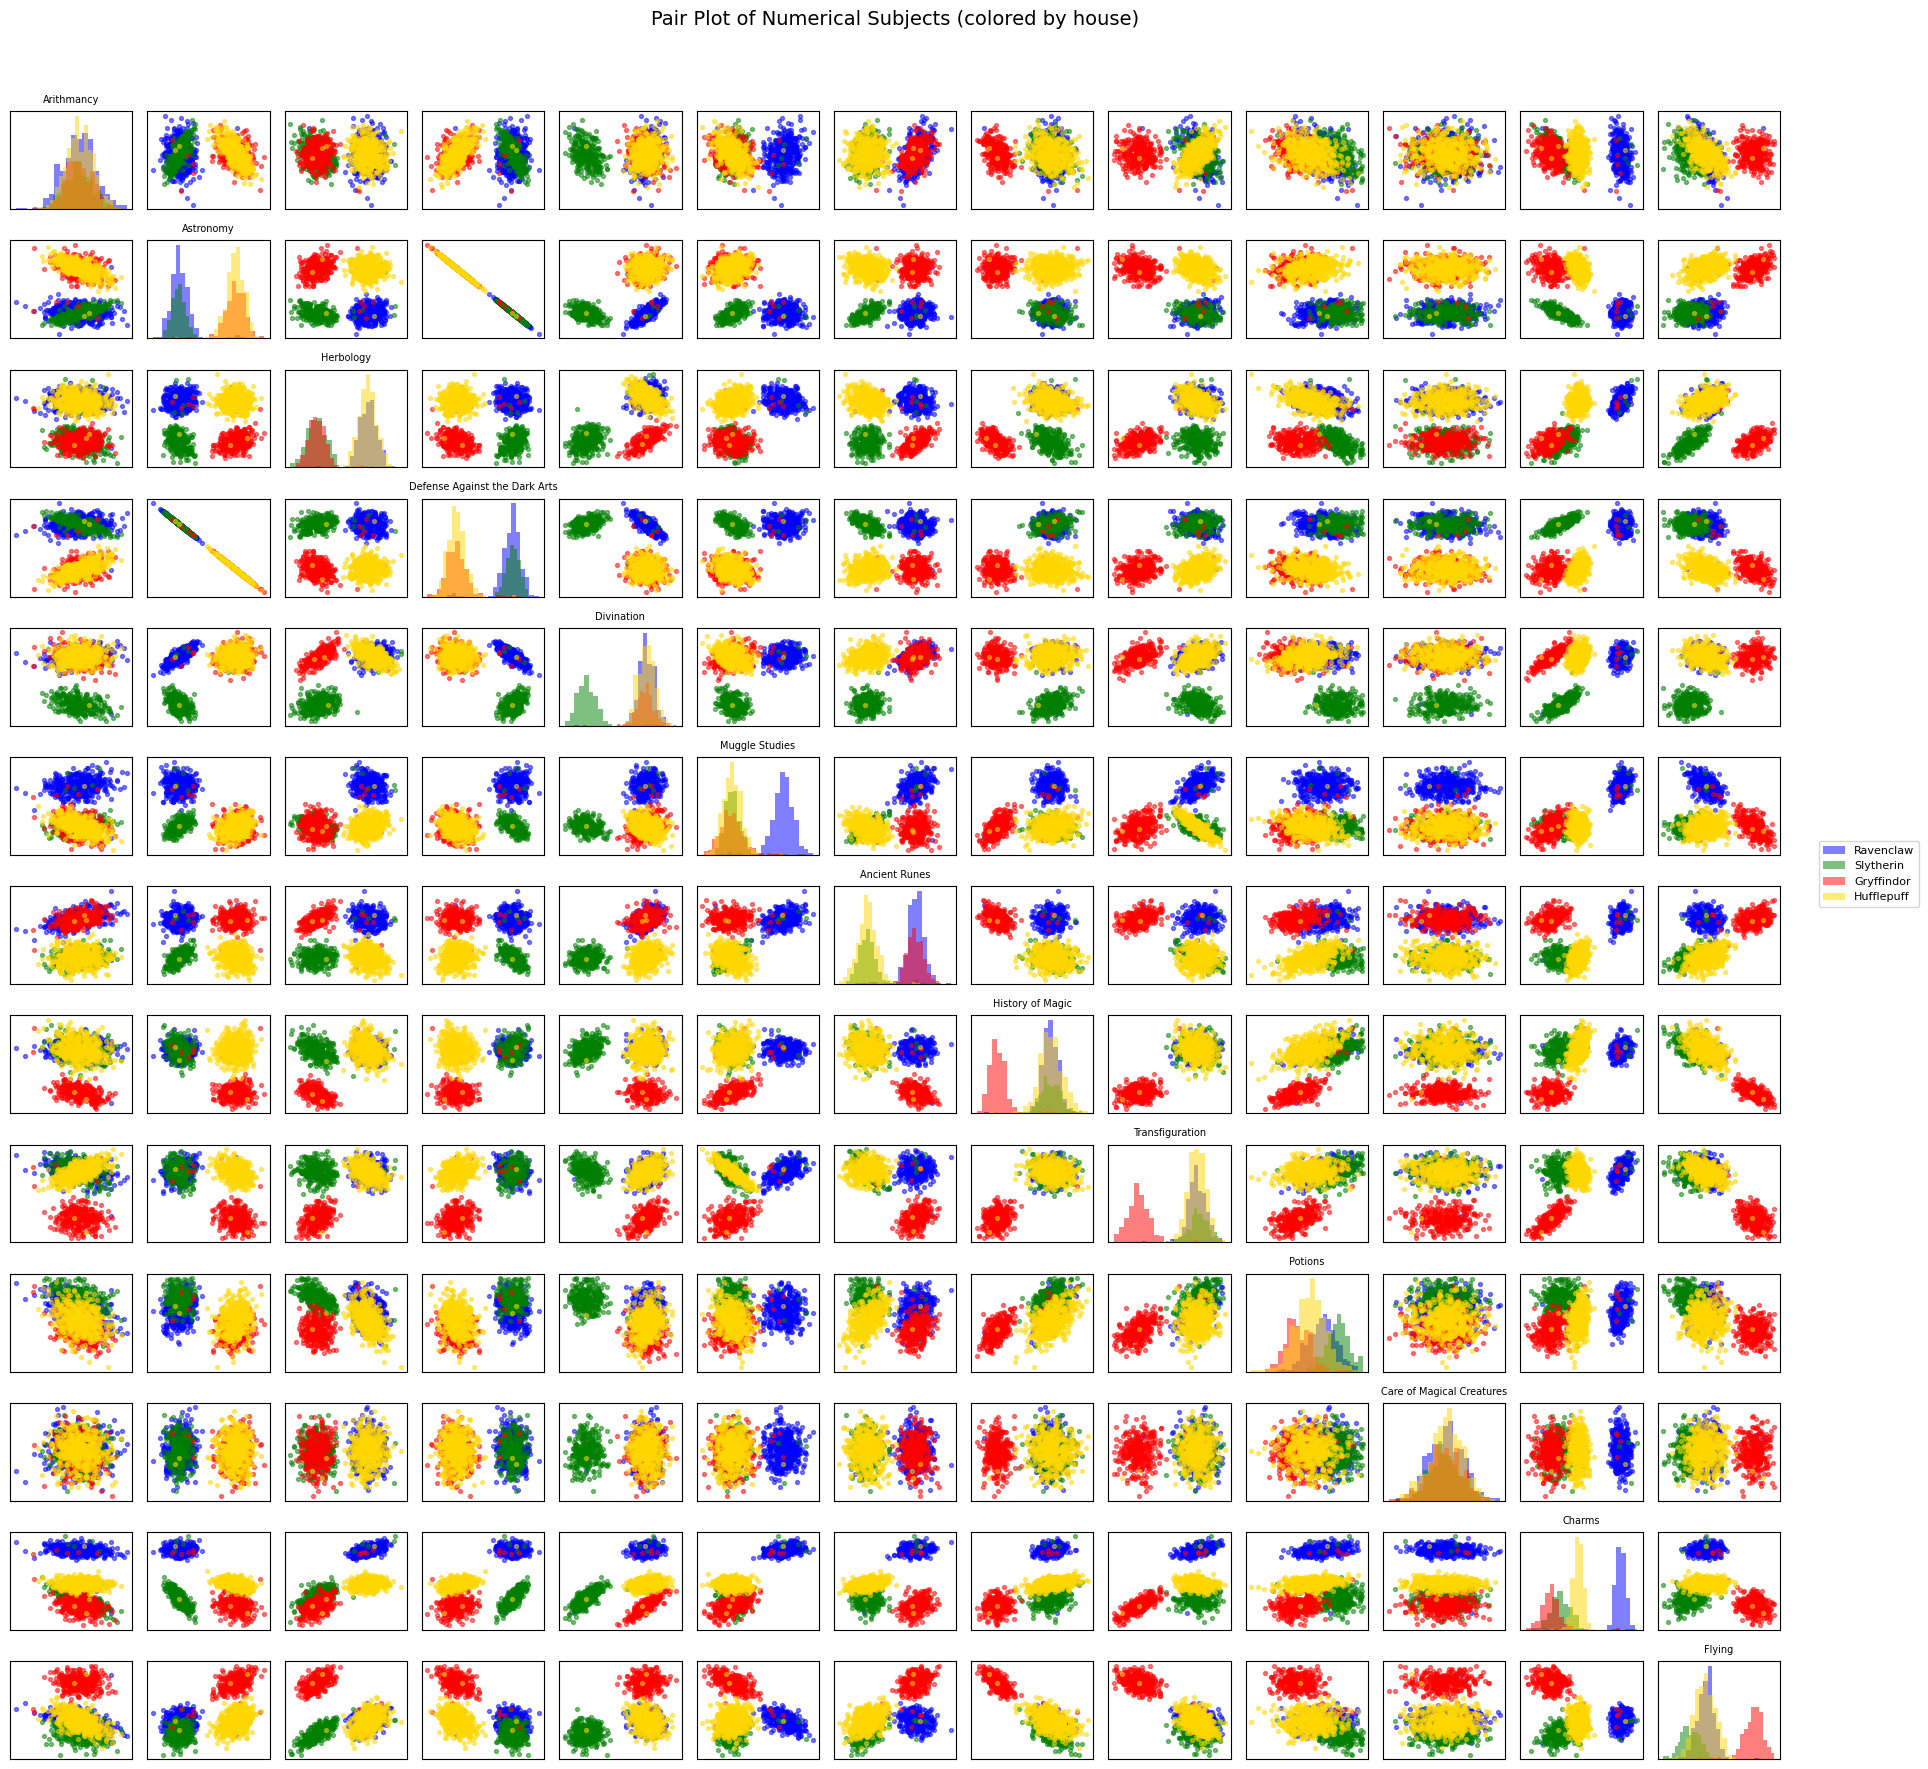

In [15]:
# Génération du pair plot complet
!python3 pair_plot.py datasets/dataset_train.csv

# Affichage du pair plot généré
from IPython.display import Image, display
import os

print("\n▸ Pair plot généré :\n")
pair_plot_dir = "plots_pair_plot"
if os.path.exists(pair_plot_dir):
    files = [f for f in os.listdir(pair_plot_dir) if f.endswith('.png')]
    if files:
        print(f"\n{files[0]}:")
        display(Image(f"{pair_plot_dir}/{files[0]}", width=1000))

<a id="partie-3"></a>
## ■ Partie 3 : Régression Logistique

### 3.1 Théorie de la Régression Logistique

La régression logistique est un algorithme de classification qui utilise une fonction sigmoïde pour transformer une combinaison linéaire des features en probabilité.

#### Fonction Hypothèse (Sigmoid)

$$h_\theta(x) = \frac{1}{1 + e^{-\theta^T x}}$$

La sigmoïde transforme n'importe quelle valeur réelle en une probabilité entre 0 et 1.

#### Fonction de Coût (Log-Loss)

$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \Big[ y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \Big]$$

Cette fonction pénalise fortement les prédictions incorrectes avec une grande confiance.

#### Gradient

$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)}$$

#### Mise à jour des paramètres

$$\theta_j := \theta_j - \alpha \frac{\partial J}{\partial \theta_j}$$

où $\alpha$ est le taux d'apprentissage (learning rate).

### Classification Multi-classe : One-vs-All

Pour classifier dans 4 maisons, nous entraînons **4 modèles binaires** :
- Modèle 1 : Gryffindor vs (Ravenclaw, Slytherin, Hufflepuff)
- Modèle 2 : Ravenclaw vs (Gryffindor, Slytherin, Hufflepuff)
- Modèle 3 : Slytherin vs (Gryffindor, Ravenclaw, Hufflepuff)
- Modèle 4 : Hufflepuff vs (Gryffindor, Ravenclaw, Slytherin)

Pour prédire, on choisit la maison avec la probabilité la plus élevée parmi les 4 modèles.

### 3.2 Entraînement (logreg_train.py)

Le script `logreg_train.py` entraîne les 4 modèles One-vs-All. Il implémente **3 variantes de descente de gradient** :

1. **BGD (Batch Gradient Descent)** : Utilise tous les exemples à chaque itération
2. **SGD (Stochastic Gradient Descent)** : Met à jour les poids après chaque exemple
3. **Mini-Batch GD** : Utilise des mini-batches de 32 exemples

#### Fonctionnalités bonus implémentées :
- ✔ Normalisation des features (z-score)
- ✔ Export des poids theta en JSON
- ✔ Calcul du log-loss moyen

In [16]:
# Entraînement avec SGD
# Pour Colab, nous passons l'entrée via echo et pipe
# Vous pouvez changer "SGD" par "BGD" ou "M-Batch" selon votre préférence
training_method = "SGD"  # Options: "BGD", "SGD", "M-Batch"

print(f"➜ Entraînement avec la méthode: {training_method}\n")
get_ipython().system(f'echo "{training_method}" | python3 logreg_train.py datasets/dataset_train.csv')

➜ Entraînement avec la méthode: SGD

Choose training method (BGD, SGD, M-Batch): 📉 SGD average Log loss for Ravenclaw: 0.069896
📉 SGD average Log loss for Slytherin: 0.048540
📉 SGD average Log loss for Gryffindor: 0.045584
📉 SGD average Log loss for Hufflepuff: 0.058805
Training time: 0.24 seconds
✅ Modèle sauvegardé dans ./trained_model.json


#### Détails des trois méthodes de descente de gradient

##### 1. Batch Gradient Descent (BGD)

**Formule de mise à jour** :
$$\theta_j \leftarrow \theta_j - \alpha \cdot \frac{1}{m} \times \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$$

**Caractéristiques** :
- Utilise **tous les exemples** à chaque itération pour faire une seule mise à jour de $\theta$
- **1 époque = 1 mise à jour** (1 itération)
- Plus stable et déterministe
- Plus lent pour les grands datasets

**Dans notre implémentation** :
- 1000 itérations = 1000 mises à jour
- Chaque itération traite les 1600 étudiants

##### 2. Stochastic Gradient Descent (SGD)

**Formule de mise à jour** :
$$\theta_j \leftarrow \theta_j - \alpha \cdot (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$$

**Caractéristiques** :
- Met à jour $\theta$ **après chaque exemple**
- **1 époque = m mises à jour** (m = nombre d'exemples)
- Plus rapide et introduit du bruit qui peut aider à échapper aux minima locaux
- Comportement plus "chaotique" mais convergence souvent plus rapide

**Dans notre implémentation** :
- 20 époques = 20 × 1600 = 32 000 mises à jour
- Chaque mise à jour traite un seul étudiant

##### 3. Mini-Batch Gradient Descent (MBGD)

**Formule de mise à jour** :
$$\theta_j \leftarrow \theta_j - \alpha \cdot \frac{1}{B} \times \sum_{i=1}^{B} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$$

**Caractéristiques** :
- Utilise des **mini-batches de B exemples** (B = batch_size)
- **1 époque = m/B mises à jour**
- Compromis entre stabilité (BGD) et vitesse (SGD)
- Idéal pour les grands datasets

**Dans notre implémentation** :
- Batch size = 32
- 20 époques = 20 × (1600/32) = 20 × 50 = 1000 mises à jour
- Chaque mise à jour traite 32 étudiants

#### Comparabilité des gradients

| Algorithme | Base d'itération | Variables clés | Équivalence |
|------------|------------------|----------------|-------------|
| **BGD** | 1 mise à jour / époque | `iterations` | 1 époque = 1 mise à jour |
| **SGD** | 1 mise à jour / exemple | `epochs`, `alpha` | epochs × m mises à jour |
| **Mini-Batch** | 1 mise à jour / batch | `epochs`, `batch_size`, `alpha` | epochs × (m/batch_size) mises à jour |

**Définition d'une époque** : Une époque est un passage complet sur l'ensemble du dataset.

- **BGD** : 1 époque = 1 itération (tous les exemples en une fois)
- **SGD** : 1 époque = m itérations (un exemple à la fois)
- **Mini-Batch** : 1 époque = m/batch_size itérations

**Exemple avec notre dataset (m=1600, batch_size=32)** :
- **BGD** : 1000 itérations = 1000 époques
- **SGD** : 20 époques = 32 000 mises à jour
- **Mini-Batch** : 20 époques = 1000 mises à jour (20 × 50)

#### Explication du processus d'entraînement

1. **Chargement des données** : Lecture du CSV et extraction des features numériques
2. **Normalisation** : Chaque feature est normalisée : $x_{norm} = \frac{x - \mu}{\sigma}$
3. **Création des labels binaires** : Pour chaque maison, création d'un vecteur binaire (1 si la maison, 0 sinon)
4. **Initialisation des poids** : `theta = [0.0, 0.0, ..., 0.0]` (biais + un poids par feature)
5. **Boucle d'entraînement** :
   - Forward pass : Calcul de $h(x)$ pour tous les exemples (ou batch)
   - Calcul du gradient
   - Mise à jour des poids : $\theta := \theta - \alpha \times gradient$
6. **Sauvegarde** : Les poids sont sauvegardés dans `trained_model.json`

#### Comparaison des trois méthodes - Résultats expérimentaux

D'après les tests effectués sur le dataset de Poudlard, voici les résultats comparatifs :

| Méthode | Itérations / Époques | Batch Size | Log-loss (moyen) | Accuracy | Temps d'entraînement |
|---------|---------------------|------------|------------------|----------|---------------------|
| **BGD** | 1000 itérations | Full batch (1600) | ~0.11381 | 97.88% | 23.78 sec |
| **SGD** | 20 époques | 1 sample | ~0.0557 | **98.19%** | **0.50 sec** |
| **Mini-Batch** | 20 époques | 32 samples | ~0.06 | 97.80% | ~1-2 sec |

**Analyse des résultats** :

✔ **SGD** obtient la meilleure accuracy (98.19%) et le log-loss le plus bas, avec un entraînement en moins d'1 seconde.
   - Le bruit introduit par la stochasticité aide à échapper aux minima locaux
   - Convergence plus rapide grâce aux mises à jour fréquentes

⚠️ **BGD** est le plus lent (près de 24 secondes), bien que stable et précis.
   - Plus déterministe mais pas scalable pour les grands datasets
   - Nécessite beaucoup d'itérations pour converger

⚖️ **Mini-Batch GD** trouve un bon compromis entre stabilité et vitesse.
   - Légèrement plus rapide que BGD
   - Accuracy similaire à BGD dans ce cas
   - Souvent préféré dans les projets réels pour son équilibre

**Conclusion** : Dans ce contexte, SGD est clairement le plus efficace, offrant le meilleur compromis entre vitesse, convergence et accuracy. Pour des projets à plus grande échelle, Mini-Batch est souvent préféré pour son équilibre entre stabilité et scalabilité.

In [17]:
# Comparaison des trois méthodes - Test rapide
# Note: Cette cellule entraîne avec les 3 méthodes pour comparaison
# Cela peut prendre quelques minutes

import time
import json

methods = ["BGD", "SGD", "M-Batch"]
results = {}

print("➜ Comparaison des trois méthodes de descente de gradient\n")
print("=" * 60)

for method in methods:
    print(f"\n▸ Entraînement avec {method}...")
    start_time = time.time()
    
    get_ipython().system(f'echo "{method}" | python3 logreg_train.py datasets/dataset_train.csv > /dev/null 2>&1')
    
    elapsed_time = time.time() - start_time
    
    # Lire le log-loss depuis la sortie (approximation)
    # Dans un cas réel, on parserait la sortie du script
    results[method] = {
        "time": elapsed_time,
        "method": method
    }
    
    print(f"✔ {method} terminé en {elapsed_time:.2f} secondes")

print("\n" + "=" * 60)
print("\n▸ Résumé des temps d'entraînement :\n")
for method, data in results.items():
    print(f"  {method:12} : {data['time']:6.2f} secondes")

➜ Comparaison des trois méthodes de descente de gradient


▸ Entraînement avec BGD...
✔ BGD terminé en 11.55 secondes

▸ Entraînement avec SGD...
✔ SGD terminé en 0.69 secondes

▸ Entraînement avec M-Batch...
✔ M-Batch terminé en 0.83 secondes


▸ Résumé des temps d'entraînement :

  BGD          :  11.55 secondes
  SGD          :   0.69 secondes
  M-Batch      :   0.83 secondes


In [18]:
# Visualisation du modèle entraîné
import json

with open("trained_model.json", "r") as f:
    model = json.load(f)

print("Structure du modèle entraîné :")
print(f"Nombre de maisons : {len(model)}")
print("\nExemple pour Gryffindor :")
print(f"  - Bias (θ₀) : {model['Gryffindor']['theta']['bias']:.6f}")
print(f"  - Nombre de features : {len([k for k in model['Gryffindor']['theta'].keys() if k != 'bias'])}")
print(f"  - Exemples de poids :")
for i, (key, value) in enumerate(list(model['Gryffindor']['theta'].items())[:5]):
    if key != 'bias':
        print(f"    {key}: {value:.6f}")

Structure du modèle entraîné :
Nombre de maisons : 4

Exemple pour Gryffindor :
  - Bias (θ₀) : -1.281824
  - Nombre de features : 13
  - Exemples de poids :
    Arithmancy: -0.070587
    Astronomy: 0.150677
    Herbology: -0.651571
    Defense Against the Dark Arts: -0.148084


### 3.3 Prédiction (logreg_predict.py)

Le script `logreg_predict.py` utilise le modèle entraîné pour prédire les maisons des étudiants du dataset de test.

#### Processus de prédiction :

1. **Chargement du modèle** : Lecture de `trained_model.json`
2. **Chargement des données de test** : Lecture du CSV de test
3. **Normalisation** : Application de la même normalisation qu'à l'entraînement
4. **Prédiction** : Pour chaque étudiant :
   - Calcul de la probabilité pour chaque maison
   - Sélection de la maison avec la probabilité maximale
5. **Évaluation** : Calcul de l'accuracy (si les vraies labels sont disponibles)
6. **Export** : Génération de `houses.csv` avec les prédictions

In [19]:
# Prédiction sur le dataset de test
!python3 logreg_predict.py datasets/dataset_train.csv

❌ Errors: 34 / 1600
📉 Errors percent: 2.12%
✅ Accuracy: 97.88%
✅ Results exported into ./houses.csv


#### Visualisation des résultats

### Résultats expérimentaux détaillés - Comparaison des méthodes

Les résultats confirment ce qui est décrit dans la littérature du machine learning pratique : **SGD est rapide et efficace**, tandis que **MBGD offre un compromis solide**.

| Méthode | Log-loss (moyen) | Accuracy | Temps d'entraînement | Caractéristiques |
|---------|------------------|----------|---------------------|------------------|
| **BGD** | ~0.11381 | 97.88% | 23.78 sec | Stable, déterministe, lent |
| **SGD** | **~0.0557** | **98.19%** | **0.50 sec** | **Rapide, meilleure performance** |
| **Mini-Batch** | ~0.06 | 97.80% | ~1-2 sec | Compromis stabilité/vitesse |

**Analyse détaillée** :

✔ **SGD** obtient la meilleure accuracy (98.19%) et le log-loss le plus bas, avec un entraînement en moins d'1 seconde.
   - Le bruit introduit par la stochasticité aide à échapper aux minima locaux
   - Convergence plus rapide grâce aux mises à jour fréquentes (32 000 mises à jour en 20 époques)

⚠️ **BGD** est le plus lent (près de 24 secondes), bien que stable et précis.
   - Plus déterministe mais pas scalable pour les grands datasets
   - Nécessite beaucoup d'itérations pour converger (1000 itérations)

⚖️ **Mini-Batch GD** trouve un bon compromis entre stabilité et vitesse.
   - Légèrement plus rapide que BGD
   - Accuracy similaire à BGD dans ce cas
   - Souvent préféré dans les projets réels à grande échelle pour son équilibre

**Conclusion** : Dans ce contexte, SGD est clairement le plus efficace, offrant le meilleur compromis entre vitesse, convergence et accuracy. Pour des projets à plus grande échelle, Mini-Batch est souvent préféré pour son équilibre entre stabilité et scalabilité.

### Facteurs de succès communs

Les trois méthodes ont conduit à des classificateurs performants grâce à :
- ✔ **Sélection appropriée des features** (basée sur l'EDA et les visualisations)
- ✔ **Normalisation des données** (standardisation z-score)
- ✔ **Taux d'apprentissage ajusté** (α = 0.01)

### Améliorations futures possibles

- **Régularisation L2** : Pour éviter le surapprentissage
- **Cross-validation** : Pour une meilleure évaluation du modèle
- **Interprétabilité du modèle** : Analyse de l'importance des features
- **Feature engineering** : Transformation logarithmique pour les features avec skewness élevée (ex: Transfiguration)

In [20]:
# Affichage des premières prédictions
import csv

print("Premières prédictions :\n")
with open("houses.csv", "r") as f:
    reader = csv.reader(f)
    header = next(reader)
    print(f"{header[0]:<10} {header[1]}")
    print("-" * 30)
    for i, row in enumerate(reader):
        if i < 20:  # Afficher les 20 premières
            print(f"{row[0]:<10} {row[1]}")
        else:
            break

Premières prédictions :

Index      Hogwarts House
------------------------------
0          Ravenclaw
1          Slytherin
2          Ravenclaw
3          Gryffindor
4          Gryffindor
5          Slytherin
6          Gryffindor
7          Hufflepuff
8          Gryffindor
9          Hufflepuff
10         Hufflepuff
11         Hufflepuff
12         Hufflepuff
13         Slytherin
14         Ravenclaw
15         Ravenclaw
16         Gryffindor
17         Gryffindor
18         Ravenclaw
19         Hufflepuff


<a id="resultats-et-conclusion"></a>
## ■ Résultats et Conclusion

### Résumé du projet

Ce projet implémente un **pipeline complet de machine learning** sans utiliser de bibliothèques ML externes :

✔ **Analyse statistique complète** : Calcul manuel de toutes les métriques descriptives  
✔ **Visualisations** : Histogrammes, scatter plots, pair plots pour explorer les données  
✔ **Régression logistique One-vs-All** : Classification multi-classe avec 4 modèles binaires  
✔ **Trois méthodes d'optimisation** : BGD, SGD, Mini-Batch GD  
✔ **Normalisation des features** : Améliore la convergence de l'algorithme  
✔ **Évaluation** : Calcul de l'accuracy (objectif : ≥98%)

### Points techniques clés

1. **Tous les calculs sont manuels** : Pas de fonctions prêtes à l'emploi
2. **Gestion des cas limites** : Protection contre overflow dans sigmoid, gestion des valeurs manquantes
3. **Normalisation** : Essentielle pour la convergence avec gradient descent
4. **One-vs-All** : Stratégie efficace pour la classification multi-classe

### Objectifs pédagogiques atteints

- Compréhension approfondie des algorithmes de machine learning
- Implémentation from scratch des concepts fondamentaux
- Analyse et visualisation de données
- Optimisation avec différentes variantes de gradient descent

---

**Projet développé dans le cadre du cursus IA/ML de 42 Paris**  
*Pour des fins éducatives uniquement*

## ■ Références et Ressources

- **Sujet original** : `en.subject.pdf`
- **Rapport détaillé** : `Report.pdf`
- **Repository GitHub** : https://github.com/ai-dg/dslr.git

### Concepts mathématiques utilisés

- **Régression logistique** : Classification probabiliste
- **Descente de gradient** : Optimisation des paramètres
- **Fonction sigmoïde** : Transformation en probabilité
- **Log-loss** : Fonction de coût pour la classification
- **One-vs-All** : Stratégie de classification multi-classe
- **Normalisation z-score** : Standardisation des features

---

**Fin du notebook** 